# APS 7BM Time-resolved Radiography

This program reads DataGrabber oscilloscope files from APS 7BM and computes raster scan maps and spectra.
It's designed to handle very large, high resolution arrays.

    @author Daniel Duke <daniel.duke@monash.edu>
    @copyright (c) 2026 D.Duke
    @license GPL-3.0+
    @version 0.0.1
    @date 26/03/2026
    
    Multiphase Flow Laboratory
    Monash University, Australia


---
Time-Resolved Radiography of Cavitating Nozzle Flow

When: 08/04/2013
Where: 7-BM, APS, Argonne National Lab
Who: Duke, Powell
Detector: Pin Diode, Femto Amp, Yokogawa DLM2000 scope for the BIM and Pin Diode
	  Yokogawa SL1000 scope and Omega Process Controllers for P3,P4 and Massflow

Note:

Scan_*.dat.gz are DataGrabber files from the Windows PC.

The DLM2k scope was set at ~6 MS/s for 20 seconds with a 1 MHz lowpass filter on the PIN channel (1) and the BIM was in channel 3.
The SL1000 scope was set to record the transducer settings and the trigger signal at 1kHz, triggered from the DLM scope.

The Femto amp gain, the conversions from voltage to pressure etc. for the SL1000 readouts, and the conditions for each scan are written in the log book for Cycle_2013_1.

This is raw data; the time-resolved signal needs to be integrated over the orbit time (ie sum up the points over the orbit time).  At 271.554 kHz, the orbit time is 3.68250882us.

---

## Stage 1 . Convert DAT files to HDF5

In [1]:
import glob, os

dg_compressed_files = glob.glob('/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/*.dat.gz')

file_path = os.path.dirname(dg_compressed_files[0])+'/'

# minor changes made to Alan's code to import, handle duplicate keys, and compressed input and output.
from Python_Library import DataGrabbertoHDF5_Multiprocess as DGtoHDF
DGtoHDF.file_path=file_path


In [6]:
# Process .dat.gz files
for dg_file in dg_compressed_files:  # TRY JUST ONE WHERE THERE'S CAVITATION

    h5_file = os.path.basename(dg_file).replace('.dat.gz','.h5')
    print('='*105)
    if os.path.isfile(file_path+'/'+h5_file): 
        #os.remove(h5_file)
        print("Skipping %s (already exists)" % os.path.basename(h5_file))
    else:
        print(os.path.basename(dg_file))
        # fconvert_file wants only the basename, as abs path specified in file_path

        DGtoHDF.fconvert_file(os.path.basename(dg_file),h5_file) # _Multiprocess version
        #DGtoHDF.fconvert_and_average_file(os.path.basename(dg_file),h5_file,path=file_path)

print("Conversion complete.")

Skipping Scan_795.h5 (already exists)
Skipping Scan_798.h5 (already exists)
Scan_799.dat.gz
FileType=DataGrabberBinary X=-0.196500 Y=0.100000 NumberOfChannels=6 TimeStamp=2013-Apr-08_20:32:34 ClockTicks=1000000 BIM=2662 PINDiode=21814 I0_APD=0 APSRingCurrent=102.2790 GasBottlePressure(psig)=1048.67628 PSBarometricPressure(psia)=14.2644 7BMMonoEnergy(keV)=8.0019 AccumChargePressure=12.0264 DrainVesselPressure=0.6255 InputT=26.5875 OutputT=27.8880

FileType=DataGrabberBinary X=-0.002000 Y=0.100000 NumberOfChannels=6 TimeStamp=2013-Apr-08_20:34:19 ClockTicks=1000000 BIM=2664 PINDiode=21779 I0_APD=0 APSRingCurrent=102.3748 GasBottlePressure(psig)=1046.54002 PSBarometricPressure(psia)=14.2653 7BMMonoEnergy(keV)=8.0019 AccumChargePressure=12.4338 DrainVesselPressure=0.6487 InputT=26.6364 OutputT=27.7534

[-0.1965, 0.1]
Replicates = 1
[-0.002, 0.1]
Replicates = 1
{'FileType': 'DataGrabberBinary', 'X': '-0.196500', 'Y': '0.100000', 'NumberOfChannels': '6', 'TimeStamp': '2013-Apr-08_20:32:34', 

/Users/dduke/src/jupyterNotebooks/Research/TimeresolvedRadiography/Python_Library/readdatagrabber.py:186: RuntimeWarning: invalid value encountered in multiply
  self.data = scale_value * self.data + offset_value


Working on position # 1, position [-0.002, 0.1]
Replicate # 0
Scan_800.dat.gz
FileType=DataGrabberBinary X=-0.202500 Y=1.199900 NumberOfChannels=6 TimeStamp=2013-Apr-08_20:36:19 ClockTicks=1000000 BIM=2654 PINDiode=21793 I0_APD=0 APSRingCurrent=101.9822 GasBottlePressure(psig)=1046.54002 PSBarometricPressure(psia)=14.2658 7BMMonoEnergy(keV)=8.0019 AccumChargePressure=12.4276 DrainVesselPressure=0.6400 InputT=26.5997 OutputT=27.7962

FileType=DataGrabberBinary X=0.003500 Y=1.999850 NumberOfChannels=6 TimeStamp=2013-Apr-08_20:38:02 ClockTicks=1000000 BIM=2658 PINDiode=21734 I0_APD=0 APSRingCurrent=101.6441 GasBottlePressure(psig)=1046.54002 PSBarometricPressure(psia)=14.2661 7BMMonoEnergy(keV)=8.0019 AccumChargePressure=12.4276 DrainVesselPressure=0.7047 InputT=26.7282 OutputT=27.7656

[-0.2025, 1.1999]
Replicates = 1
[0.0035, 1.99985]
Replicates = 1
{'FileType': 'DataGrabberBinary', 'X': '-0.202500', 'Y': '1.199900', 'NumberOfChannels': '6', 'TimeStamp': '2013-Apr-08_20:36:19', 'ClockTi

---
## Stage 2. Bin the time-series and remove the bunch-charge variations

We just want one data point per synchrotron pulse to give ~6.5 MHz time resolution.

In [1]:
import h5py, os, glob, time
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
%matplotlib widget

file_path='/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM'
hdf5_files = glob.glob(file_path+'/*.h5')

In [2]:
import sys
cython_lib_dir='/Users/dduke/src/jupyterNotebooks/Research/TimeresolvedRadiography/Python_Library'
if not cython_lib_dir in sys.path:
    print("Added to sys.path")
    sys.path.insert(1, cython_lib_dir)

from Python_Library import ArrayBinModule

Added to sys.path


### Run a test on one timeseries

(125000000,) (124462248,)


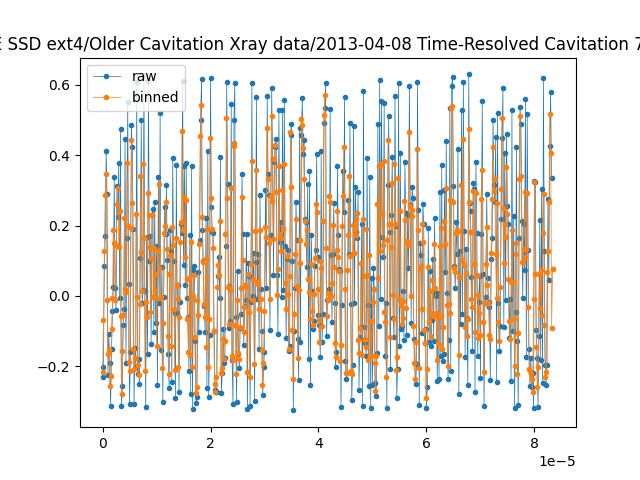

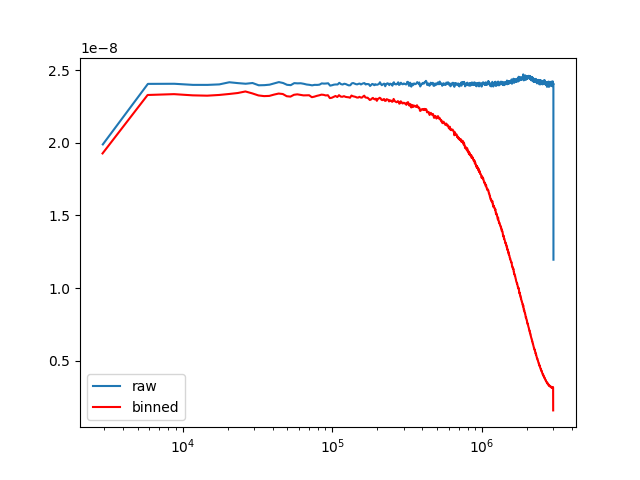

In [47]:
# Find suitable point in the scan where there is something worth looking at
import scipy.signal

with h5py.File(hdf5_files[0],'r') as H:

    Xcoord = H['X'][...]
    Ycoord = H['Y'][...]

    #fig=plt.figure()
    #plt.scatter(Xcoord, Ycoord);
    #plt.xlabel('X [mm]');plt.ylabel('Y [mm]');

    j=5
    data = H['PINDiode'][j,:,0]
    data /= np.nanmean(H['BIM'][j,:,0])
    
    
    pulse_time=1./271554./22.
    repeat_num=22
    start_time=0
    output_data, pulse_time_out, start_point = ArrayBinModule.fbin_signal_fixed_time(data.astype(np.float64),\
                                                                      dt,pulse_time,repeat_num,start_time)

    #output_data, pulse_time_out, start_point = ArrayBinModule.fbin_signal_by_pulse(data.astype(np.float64),\
    #                                                                   dt,pulse_time,repeat_num,start_time)

    print(data.shape,output_data.shape)
    
    fig=plt.figure()
    plt.title(hdf5_files[0])
    fs=6e6
    dt=1./fs
    plt.plot(np.arange(500)*dt, -np.log(data[:500]),lw=.5,marker='.',label='raw');
    plt.plot(np.arange(500)*pulse_time_out, -np.log(output_data[:500]),lw=.5,marker='.',label='binned');
    plt.legend();
    
    fig=plt.figure()
    f,s = scipy.signal.welch(-np.log(data),fs=fs,nperseg=2048)
    plt.semilogx(f[1:],s[1:],label='raw')
    ddf = -np.log(output_data)
    ddf[np.isnan(ddf)]=0
    ddf[np.isinf(ddf)]=0
    fb,sb = scipy.signal.welch(ddf,fs=1./pulse_time_out,nperseg=2048)
    #ax=plt.gca().twinx()
    plt.semilogx(fb[1:],sb[1:],label='binned',c='r')
    #plt.ylim(s[1:].min(),s[1:].max())
    plt.legend();


### Summary of AK's functions

**def fbin_signal_fixed_time(input_array,delta_t,pulse_time=None,repeat_num=None,start_time=0)**

Function to read in signal, binning by fixed bin time bin_time.

Inputs:
- input_array: array of input data.
- delta_t: time period between measurement points in the original array.
- pulse_time: Initial estimate of the time between pulses.
- repeat_num: if the pulses have a repeating pattern, how many pulses per period.
- start_point: where should integration begin.

Outputs:
- output_data: binned signal 
- pulse_time: updated measurement of the time between pulses
- start_point * delta_t: where did we really begin integration

**def fbin_signal_by_pulse(input_array,delta_t,pulse_time=None,repeat_num=1,start_time=0)**

Bin a peaked signal with a regular period by each peak.  

Code finds the peak spacing.  Peaks need not be at integer spacing.

Inputs:
- input array: array of peaked input data.
- delta_t: time period between measurement points in the original array.
- pulse_time: Initial estimate of the time between pulses.
- repeat_num: if the pulses have a repeating pattern, how many pulses per period.
- start_time: where should integration begin.  Only here to match fbin_signal_fixed_time

Outputs:
- output_data: binned signal 
- pulse_time: updated measurement of the time between pulses
- start_point * delta_t: where did we really begin integration
    

### Batch-process data with appropriate settings

Write the binned PIN and BIM data back into the hdf5 files

In [3]:
pulse_time=1./271554./22.
repeat_num=22
start_time=0
skip_processed=True # if False, overwrite.

def process_one(filename, i):
    with h5py.File(filename,'a') as H:

        # Read
        pin = H['PINDiode'][i,...]
        I0 = H['BIM'][i,...]
        dt = float(H['PINDiode'].attrs['TimeStep'])

        if len(pin.shape)>1: pin=pin[:,0]
        if len( I0.shape)>1: I0=I0[:,0]

        # Process
        output_pin, pulse_time_out, start_point = ArrayBinModule.fbin_signal_fixed_time(pin.astype(np.float64),\
                                                                          dt,pulse_time,repeat_num,start_time)

        output_I0, pulse_time_out0, start_point0 = ArrayBinModule.fbin_signal_fixed_time(I0.astype(np.float64),\
                                                                          dt,pulse_time,repeat_num,start_time)

        # Write
        if not 'PIN_binned' in H:
            H.create_dataset('PIN_binned', (H['PINDiode'].shape[0], len(output_pin)), chunks=(1,len(output_pin)),\
                            dtype=np.float64, compression='lzf')
            H['PIN_binned'].attrs['pulse_time']=pulse_time_out
            H['PIN_binned'].attrs['start_point']=start_point
            
        H['PIN_binned'][i,:]=output_pin
        
        if not 'I0_binned' in H:
            H.create_dataset('I0_binned', (H['BIM'].shape[0], len(output_I0)), chunks=(1,len(output_I0)),\
                            dtype=np.float64, compression='lzf')
            H['I0_binned'].attrs['pulse_time']=pulse_time_out0
            H['I0_binned'].attrs['start_point']=start_point0
            
        H['I0_binned'][i,:]=output_I0

    return

In [4]:
for filename in hdf5_files:
    t0=time.time()
    
    # Get size of data
    with h5py.File(filename,'a') as H:
        print(filename)

        # Check if we need to delete previous
        if ('PIN_binned' in H) and skip_processed:
            print("\tFile already processed, skipping to next")
            continue
        else:
            if 'PIN_binned' in H: 
                print("\tOverwriting existing binned arrays")
                del H['PIN_binned']
            if 'I0_binned' in H: del H['I0_binned']

        # Get number of sample points to process
        npts = H['PINDiode'].shape[0]
        
        # Report size of arrays
        print("\tPINDiode array size:",H['PINDiode'].shape)
        print("\tBIM array size:",H['BIM'].shape)

    # Loop over positions - open and close file each time to flush 
    for i in range(npts): # loop serially given large RAM requirement of timeseries. Could be parallelised
        print("\tbinning %i/%i" % (i+1,npts))
        process_one(filename, i)
        
    print("\tcompleted in %.0f s.\n" % (time.time()-t0))

print("all files processed.")

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_797.h5
	PINDiode array size: (34, 125000000, 2)
	BIM array size: (34, 125000000, 2)
	binning 1/34
	binning 2/34
	binning 3/34
	binning 4/34
	binning 5/34
	binning 6/34
	binning 7/34
	binning 8/34
	binning 9/34
	binning 10/34
	binning 11/34
	binning 12/34
	binning 13/34
	binning 14/34
	binning 15/34
	binning 16/34
	binning 17/34
	binning 18/34
	binning 19/34
	binning 20/34
	binning 21/34
	binning 22/34
	binning 23/34
	binning 24/34
	binning 25/34
	binning 26/34


/Users/dduke/src/jupyterNotebooks/Research/TimeresolvedRadiography/Python_Library/ArrayBinModule.py:105: RuntimeWarning: invalid value encountered in divide
  multiplier /= np.nanmean(multiplier,dtype=np.float64)


	binning 27/34
	binning 28/34
	binning 29/34
	binning 30/34
	binning 31/34
	binning 32/34
	binning 33/34
	binning 34/34
	completed in 934 s.

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_800.h5
	PINDiode array size: (2, 125000000)
	BIM array size: (2, 125000000)
	binning 1/2
	binning 2/2
	completed in 44 s.

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_801.h5
	PINDiode array size: (2, 125000000)
	BIM array size: (2, 125000000)
	binning 1/2
	binning 2/2
	completed in 43 s.

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_796.h5
	PINDiode array size: (35, 125000000)
	BIM array size: (35, 125000000)
	binning 1/35
	binning 2/35
	binning 3/35
	binning 4/35
	binning 5/35
	binning 6/35
	binning 7/35
	binning 8/35
	binning 9/35
	binning 10/35
	binning 11/35
	binning 12/35
	binning 13/35
	binning 14/35
	binning 15/35
	binning 16/35
	binning 17/35
	bi

In [14]:
# delete output from a file if required.
#with h5py.File('/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_802.h5','a') as H:
#    del H['PIN_binned']
#    del H['I0_binned']

---
## Stage 3. Compute the spectra

In [1]:
import h5py, os, glob, time
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import scipy.signal
%matplotlib widget

file_path='/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM'
hdf5_files = glob.glob(file_path+'/Scan*.h5')

In [3]:
def ff(data_in):
    # take logarithm and filter data in preparation for spectra.
    data_out = -np.log(data_in)
    data_out[np.isnan(data_out)]=0
    data_out[np.isinf(data_out)]=0
    return data_out
    
def process_file(filename, plot_spectra=False):
    pin_spectra_lo = []
    pin_spectra_hi = []
    I0_spectra_lo = []
    I0_spectra_hi = []
    timeavg_stats = []
    t0=time.time()

    
    with h5py.File(filename,'r') as H:
        print(filename)
        
        #if 'postprocessed' in H:
        #    print("\tThis file already processeed. Skipping")
        #    return
        
        pinData = H['PIN_binned']
        I0Data = H['I0_binned']
        dt = H['PIN_binned'].attrs['pulse_time']

        if len(pinData.shape)>2:
            raise IndexError(str(pinData.shape))

        N = pinData.shape[0]
        for i in range(N):
            print('\t%i / %i' % (i+1,N))
            t0=time.time()

            pin_ = ff(pinData[i,:]) # take -ve log & filter out -ve.
            i0_  = ff(I0Data[i,:])  # take -ve log & filter out -ve.

            pin_ -= np.nanmean(i0_) # for pin, just normalize by time-average i0.
            
            # Time-average
            timeavg_stats.append([ np.nanmean(pin_), np.nanstd(pin_),\
                                   np.nanmean(i0_), np.nanstd(i0_) ])

            # Spectra (welch method)
            nn=2**20 # big window, low frequencies
            f_lo, P00_lo = scipy.signal.welch(i0_,1./dt,nperseg=nn)#,noverlap=int(nn*3/4))
            f_lo, P11_lo = scipy.signal.welch(pin_,1./dt,nperseg=nn)#,noverlap=int(nn*3/4))
            
            nn=2**11 # small window, high frequencies
            f_hi, P00_hi = scipy.signal.welch(i0_,1./dt,nperseg=nn)
            f_hi, P11_hi = scipy.signal.welch(pin_,1./dt,nperseg=nn)

            # Save result to list
            I0_spectra_lo.append(P00_lo)
            I0_spectra_hi.append(P00_hi)
            pin_spectra_lo.append(P11_lo)
            pin_spectra_hi.append(P11_hi)

            time_elapsed = time.time()-t0
            
            # Plot result?
            if plot_spectra:
                fig=plt.figure()
                plt.suptitle(os.path.basename(filename))
                plt.title("i=%i" % i)
                plt.loglog(f_lo,P11_lo,label='PIN = %g ± %g' % tuple(timeavg_stats[-1][:2]),lw=.5)
                plt.loglog(f_lo,P00_lo,label='I0 = %g ± %g' % tuple(timeavg_stats[-1][2:]),lw=.5)
                plt.loglog(f_hi,P11_hi,label='PIN hi',lw=1)
                plt.loglog(f_hi,P00_hi,label='I0 hi',lw=1)
                plt.legend();
            
                print('\tfull f range %.2f-%.2f Hz in %i bins, time record %g s' % (f_lo[1],f_lo[-1],len(f_lo),dt*pinData.shape[1]))
                print('\thigh f range %.2f-%.2f Hz in %i bins, took %.2f s' % (f_hi[1],f_hi[-1],len(f_hi),time_elapsed))

            del pin_
            del i0_
    
    # Save results from lists to HDF5 back into same file as a new group of datasets.
    with h5py.File(filename,'a') as HO:
        if 'postprocessed' in HO:
            print("\tOverwriting previous result!")
            del HO['postprocessed']
            
        GO = HO.create_group('postprocessed')
        G1 = GO.create_group('spectra_lo')
        G2 = GO.create_group('spectra_hi')
        G3 = GO.create_group('time_avg')
        
        G1.create_dataset('freq',data=f_lo,compression='lzf')
        G2.create_dataset('freq',data=f_hi,compression='lzf')

        d_pin_mean=G3.create_dataset('PIN_mean',(N,),compression='lzf')
        d_I0_mean=G3.create_dataset('I0_mean',(N,),compression='lzf')
        d_pin_std=G3.create_dataset('PIN_std',(N,),compression='lzf')
        d_I0_std=G3.create_dataset('I0_std',(N,),compression='lzf')
        
        
        d_pin_spectra_lo=G1.create_dataset('PIN_spectra',(N,len(pin_spectra_lo[0])),\
                                           chunks=(1,len(pin_spectra_lo[0])), dtype='float64',compression='lzf')

        d_pin_spectra_hi=G2.create_dataset('PIN_spectra',(N,len(pin_spectra_hi[0])),\
                                           chunks=(1,len(pin_spectra_hi[0])), dtype='float64',compression='lzf')

        d_I0_spectra_lo=G1.create_dataset('I0_spectra',(N,len(I0_spectra_lo[0])),\
                                           chunks=(1,len(I0_spectra_lo[0])), dtype='float64',compression='lzf')

        d_I0_spectra_hi=G2.create_dataset('I0_spectra',(N,len(I0_spectra_hi[0])),\
                                           chunks=(1,len(I0_spectra_hi[0])), dtype='float64',compression='lzf')
        
        for i in range(N):
            d_pin_spectra_lo[i,:] = pin_spectra_lo[i]
            d_pin_spectra_hi[i,:] = pin_spectra_hi[i]
            d_I0_spectra_lo[i,:] = I0_spectra_lo[i]
            d_I0_spectra_hi[i,:] = I0_spectra_hi[i]
            d_pin_mean[i] = timeavg_stats[i][0]
            d_pin_std[i] = timeavg_stats[i][1]
            d_I0_mean[i] = timeavg_stats[i][2]
            d_I0_std[i] = timeavg_stats[i][3]
    
    return
    

In [4]:
for filename in hdf5_files:
    print("")
    process_file(filename,plot_spectra=False)
    #break
    
print("Processing complete.")


/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_797.h5
	1 / 34
	2 / 34
	3 / 34
	4 / 34
	5 / 34
	6 / 34
	7 / 34
	8 / 34
	9 / 34
	10 / 34
	11 / 34
	12 / 34
	13 / 34
	14 / 34
	15 / 34
	16 / 34
	17 / 34
	18 / 34
	19 / 34
	20 / 34
	21 / 34
	22 / 34
	23 / 34
	24 / 34
	25 / 34


/var/folders/6z/v83wfyrn4pqdkbl08lfx_pgmvzd0gj/T/ipykernel_14305/4246969309.py:3: RuntimeWarning: divide by zero encountered in log
  data_out = -np.log(data_in)


	26 / 34
	27 / 34
	28 / 34
	29 / 34
	30 / 34
	31 / 34
	32 / 34
	33 / 34
	34 / 34
	Overwriting previous result!

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_800.h5
	1 / 2
	2 / 2
	Overwriting previous result!

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_801.h5
	1 / 2
	2 / 2
	Overwriting previous result!

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_796.h5
	1 / 35
	2 / 35
	3 / 35
	4 / 35
	5 / 35
	6 / 35
	7 / 35
	8 / 35
	9 / 35
	10 / 35
	11 / 35
	12 / 35
	13 / 35
	14 / 35
	15 / 35
	16 / 35
	17 / 35
	18 / 35
	19 / 35
	20 / 35
	21 / 35
	22 / 35
	23 / 35
	24 / 35
	25 / 35
	26 / 35
	27 / 35
	28 / 35
	29 / 35
	30 / 35
	31 / 35
	32 / 35
	33 / 35
	34 / 35
	35 / 35
	Overwriting previous result!

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_795.h5
	1 / 35
	2 / 35
	3 / 35
	4 / 35
	5 / 35
	6 / 35
	7 / 

---

## Stage 4. Check the Spectra

In [1]:
import h5py, os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib widget

file_path='/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM'
hdf5_files = glob.glob(file_path+'/Scan*.h5')

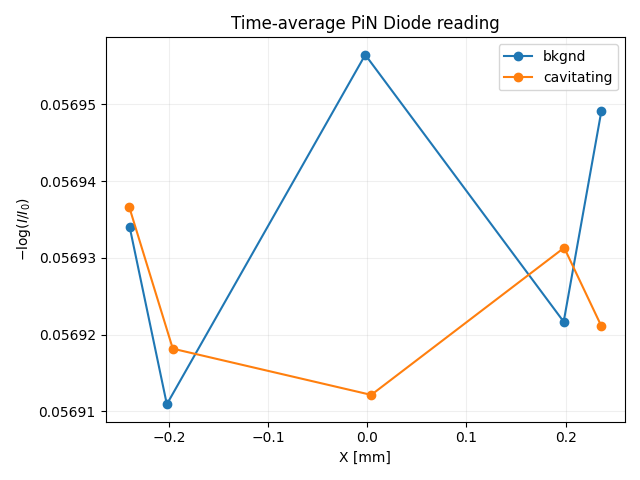

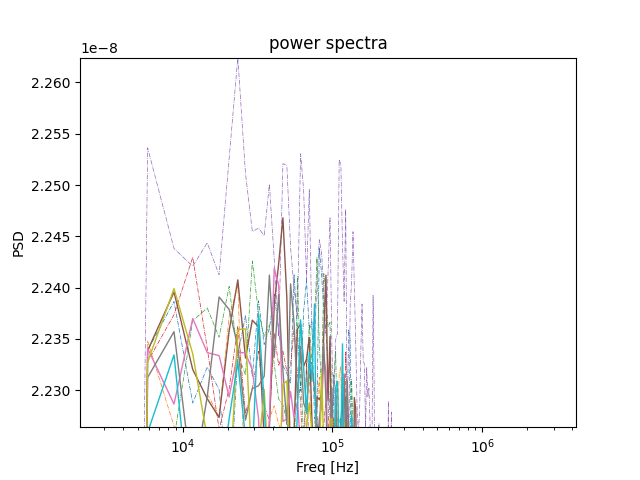

In [19]:
# Get bkgnd spectra

HB = h5py.File(file_path+'/Scan_795.h5','r')
H  = h5py.File(file_path+'/Scan_797.h5','r')

n0=5
n1=9

xb = HB['X'][n0:n1+1,0]
yb = HB['Y'][n0:n1+1,0]
datab = HB['postprocessed/time_avg/PIN_mean'][n0:n1+1] # this is -log(pin/meanI0)

x = H['X'][n0:n1+1,0]
y = H['Y'][n0:n1+1,0]
data = H['postprocessed/time_avg/PIN_mean'][n0:n1+1] # this is -log(pin/meanI0)

fig=plt.figure()
plt.grid(alpha=.2);
plt.plot(xb,datab,marker='o',label='bkgnd');
plt.plot(x,data,marker='o',label='cavitating');
plt.title("Time-average PiN Diode reading");
plt.legend();
plt.xlabel('X [mm]');
plt.ylabel(r'$-\log(I/I_0)$');
plt.tight_layout();

fb = HB['postprocessed/spectra_hi/freq'][:]
Sb = HB['postprocessed/spectra_hi/PIN_spectra'][n0:n1+1,:]

f  = H['postprocessed/spectra_hi/freq'][:]
S  = H['postprocessed/spectra_hi/PIN_spectra'][n0:n1+1,:]

fig=plt.figure()
plt.semilogx(fb, np.transpose(Sb), lw=.5, ls='-.');
plt.semilogx(f , np.transpose(S), lw=1);
plt.xlabel('Freq [Hz]');
plt.ylabel('PSD');
plt.title('power spectra');
plt.ylim(Sb[2,2],np.nanmax(Sb));

HB.close();
H.close();


---
## Stage 4B. Merge datasets so we have one per experimental condition

Using logbook information.


In [1]:
import h5py, os, glob, time, itertools
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

file_path='/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM'
hdf5_files = glob.glob(file_path+'/*.h5')

In [2]:
experiment_scans=[np.arange(799,803+1),(804,805,808),\
                  np.arange(810,814+1),(795,),(796,),(798,797)]
experiments=['P3_10bar_increasingBackPressure','P3_10bar_decreasingBackPressure',\
            'P3_10bar_increasingBackPressure2','P3_10bar_bkgnd','P3_10bar__P4_0.9bar','P3_10bar__P4_0.5bar']

In [4]:
for i in range(len(experiment_scans)):
  try:
    print(experiments[i],'\t:',experiment_scans[i])

    #output file
    output_filename=os.path.dirname(hdf5_files[0])+'/'+experiments[i]+'.h5'
    if os.path.isfile(output_filename): continue # skip existing?
    
    HO = h5py.File(output_filename,'w') # force overwrite of output
    
    # Find matching files, requiring just that the scan number appears *somewhere* in the filename
    for filename in itertools.chain.from_iterable([ [f for f in hdf5_files if str(n) in os.path.basename(f) ] \
                                                    for n in experiment_scans[i]]):

        
        with h5py.File(filename,'r') as H:
            print('\t',os.path.basename(filename), '\thas',H['X'].shape[0],' points')
            #print('\tP1 ~',np.nanmean(H['AccumChargePressure'][:,0]),'\tP2 ~',np.nanmean(H['DrainVesselPressure'][:,0]))
            print('\t\tx in [',np.nanmin(H['X'][:,0]),np.nanmax(H['X'][:,0]),\
                  ']\ty in [',np.nanmin(H['Y'][:,0]),np.nanmax(H['Y'][:,0]),']')
            

            # subgroup or merge?
            GO = HO#.create_group(os.path.splitext(os.path.basename(filename))[0])

            # find all ds recursively
            datasets=[]
            def get_datasets(name):
                # 'f[name]' retrieves the actual object (group or dataset)
                if isinstance(H[name], h5py.Dataset):
                    datasets.append(name)
            H.visit(get_datasets)
            
            
            for k in datasets:
                
                if k in ['BIM','BIM 1','PINDiode','PINDiode 1']: 
                    # Do not copy unbinned (raw) signals, no longer needed.
                    pass #print("\t\t- skip",k)
                    
                elif k in GO:
                    # append to existing
                    sz1 = GO[k].shape
                    sz2 = H[k].shape
                    #print(k,sz1,sz2)
                    if len(sz2)>=2:
                        if (len(sz2)>len(sz1)):
                            print("\t\tignoring 3rd dimension of",k,sz)
                            GO[k].resize((sz1[0]+sz2[0],sz2[1]))
                            GO[k][sz1[0]:sz1[0]+sz2[0], ...] = H[k][...,0] # add to 1st axis
                        else:
                            GO[k].resize((sz1[0]+sz2[0],sz2[1]))
                            GO[k][sz1[0]:sz1[0]+sz2[0], ...] = H[k][...] # add to 1st axis
                    elif len(sz2)==1:
                        if 'time_avg' in k: # scalar- append to end of 1st axis
                            print('\t\t',k,GO[k].shape)
                            GO[k].resize((sz1[0]+sz2[0],1))
                            GO[k][sz1[0]:,0] = H[k][:]
                            print('\t\t',k,GO[k].shape)
                        else: # vector - grow 1st axis, vector goes in 2nd axis.
                            GO[k].resize((sz1[0]+1,sz2[0]))
                            GO[k][-1, :] = H[k][:]
                        
                    else:
                        print("HOW TO APPEND?\t", k, GO[k].shape, H[k].shape)
                        raise RuntimeError

                    #print('\t\t', k, GO[k].shape)
                    #raise RuntimeError
                        
                elif type(H[k]) is h5py.Dataset:
                    # initial copy - make a resizable, compressed, chunked dataset
                    sz = H[k].shape
                    if len(sz)==2: # 2d array
                        # expand along 1st axis of 2d
                        maxsz1=sz[1]
                        if sz[1]==1: maxsz1=10
                        ds = GO.create_dataset(k, sz, chunks=(1, sz[1]), maxshape=(None, maxsz1), compression='lzf', dtype=H[k].dtype)
                        ds[...]=H[k][...] # copy data
                    elif len(sz)==1: # add new 1st axis for expansion
                        if ('time_avg' in k) and True: # transposed data?
                            ds = GO.create_dataset(k, (sz[0],1), maxshape=(None, 1), compression='lzf', dtype=H[k].dtype)
                            ds[:,0]=H[k][:] # copy data
                        else:
                            ds = GO.create_dataset(k, (1,sz[0]), maxshape=(None, sz[0]*2), compression='lzf', dtype=H[k].dtype)
                            ds[0,:]=H[k][:] # copy data
                    elif len(sz)==3: # expand along 1st axis of 2d, assume data only in first slice of 3rd dim.
                        print("\t\tignoring 3rd dimension of",k,sz)
                        ds = GO.create_dataset(k, sz[:2], chunks=(1, sz[1]), maxshape=(None, sz[1]*2), compression='lzf', dtype=H[k].dtype)
                        ds[...]=H[k][:,:,0] # copy data, only first slice of 3rd dim.
                    else:
                        print(k,H[k],sz)
                        raise RuntimeError

    HO.close()
    
    print("")
    
  except:
    HO.close()
    raise

print("Done")
    

P3_10bar_increasingBackPressure 	: [799 800 801 802 803]
P3_10bar_decreasingBackPressure 	: (804, 805, 808)
P3_10bar_increasingBackPressure2 	: [810 811 812 813 814]
P3_10bar_bkgnd 	: (795,)
P3_10bar__P4_0.9bar 	: (796,)
P3_10bar__P4_0.5bar 	: (798, 797)
	 Scan_798.h5 	has 2  points
		x in [ -0.24 -0.1965 ]	y in [ 2.7998 2.7998 ]
	 Scan_797.h5 	has 34  points
		x in [ -0.24 0.236 ]	y in [ 0.0999 2.99985 ]
		ignoring 3rd dimension of BackPressure (2,)
		ignoring 3rd dimension of InletPressure (2,)
		ignoring 3rd dimension of MassFlow (2,)
		ignoring 3rd dimension of Trigger (2,)
		 postprocessed/time_avg/I0_mean (2, 1)
		 postprocessed/time_avg/I0_mean (36, 1)
		 postprocessed/time_avg/I0_std (2, 1)
		 postprocessed/time_avg/I0_std (36, 1)
		 postprocessed/time_avg/PIN_mean (2, 1)
		 postprocessed/time_avg/PIN_mean (36, 1)
		 postprocessed/time_avg/PIN_std (2, 1)
		 postprocessed/time_avg/PIN_std (36, 1)

Done


---
## Stage 5. Plot spectra

Find coordinates on nozzle grid, and get background and foreground spectra.

In [34]:
import h5py, os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib widget

file_path='/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM'
hdf5_files = glob.glob(file_path+'/P3*.h5')

In [344]:
def plot_nozzle_coords(ax=None):
    if ax is None: 
        fig=plt.figure(figsize=(10,2))
        ax=fig.add_subplot(111)
    plt.xlabel('X/D')
    plt.ylabel('Y/D')
    plt.grid(alpha=.2)
    plt.ylim([-.6,.6]) # add 0.1D each side
    plt.xlim([-1,7.1]) # add 1D each side
    ax.set_aspect(1.); # realistic aspect ratio
    
    rect1 = mpl.patches.Rectangle((0,0.5),L/D,0.1,lw=1,ec='k',fc='None',hatch='//');
    rect2 = mpl.patches.Rectangle((0,-0.5),L/D,-0.1,lw=1,ec='k',fc='None',hatch='//');
    ax.add_patch(rect1);
    ax.add_patch(rect2);
    ax.annotate("flow", xytext=(-0.8, 0), xy=(0, 0), arrowprops=dict(arrowstyle="->"), va='center')

    return ax

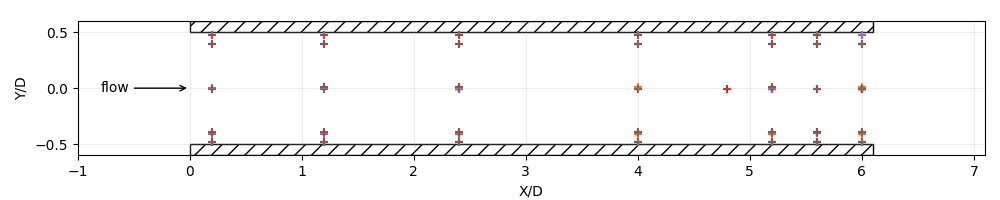

In [345]:
ax=plot_nozzle_coords()
for filename in hdf5_files:
    with h5py.File(filename,'r') as H:
        L=3.05; D=0.5;
        
        # transpose axes and nondimensionalise
        x = H['Y'][...]/D
        y = H['X'][...]/D

        # Make plot of nozzle showing where grid points are.
        
        ax.scatter(x[:,0], y[:,0],marker='+',label=os.path.splitext(os.path.basename(filename))[0])
        

        # Make plot of mean field
        #fig=plt.figure(figsize=(10,4))
        #beerLaw = -np.log(H['postprocessed/time_avg/PIN_mean'][...]/H['postprocessed/time_avg/I0_mean'][...])
        #print(beerLaw.shape);
        

fig.legend(loc='outside right upper');
plt.tight_layout();

---
## Stage 6. Plot the spectra

- Spectral integrals
- Transverse average spectra

In [357]:
def get_combined_spectra(H):

    f_hi = H['postprocessed/spectra_hi/freq'][0,:]
    Pxx_hi = H['postprocessed/spectra_hi/PIN_spectra'][...]

    f_lo = H['postprocessed/spectra_lo/freq'][0,:]
    Pxx_lo = H['postprocessed/spectra_lo/PIN_spectra'][...]

    # truncate Pxx_lo where Pxx_hi starts. Pxx_lo is noisier(nfft larger).
    s=2
    ww=8
    f_crossover=f_hi[s]
    i_crossover=np.where(f_lo>=f_hi[1])[0][0] + ww

    # apply smoothing to Pxx_lo as it is noisier
    Pxx_lo_proc = Pxx_lo[:,:i_crossover]
    #window = np.hanning(ww)
    #for k in range(Pxx_lo_proc.shape[0]):
    #    Pxx_lo_proc[k,:] = np.convolve(Pxx_lo[k,:i_crossover],window/np.sum(window),'same')

    # return with no gap
    return np.hstack((f_lo[:i_crossover-ww//4], f_hi[s:])), np.hstack((Pxx_lo_proc[:,:-ww//4], Pxx_hi[:,s:]))
    
    # return with gap between merged datasets
    O=np.zeros((Pxx_lo_proc.shape[0],1)); O[:]=np.nan
    return np.hstack((f_lo[:i_crossover-ww//2], [np.nan], f_hi[s:])), np.hstack((Pxx_lo_proc[:,:-ww//2], O, Pxx_hi[:,s:]))

In [359]:
# Select file and set up parameters for this experiment
fg_data = hdf5_files[-2]
print(os.path.basename(fg_data))

dP=10e5 - 0.9e5# Pa
rhol=850 # kg/m^3
L=3.05; # mm
D=0.5; # mm

def Strouhal(f_,dP=None):
    dischargeCoeff = 0.611
    U = dischargeCoeff*np.sqrt(2*dP/rhol)
    return f_*D*1e-3/U

def smooth(P):
    window=np.hanning(64)
    return np.convolve(P,window/np.nansum(window),'same')

P3_10bar__P4_0.9bar.h5


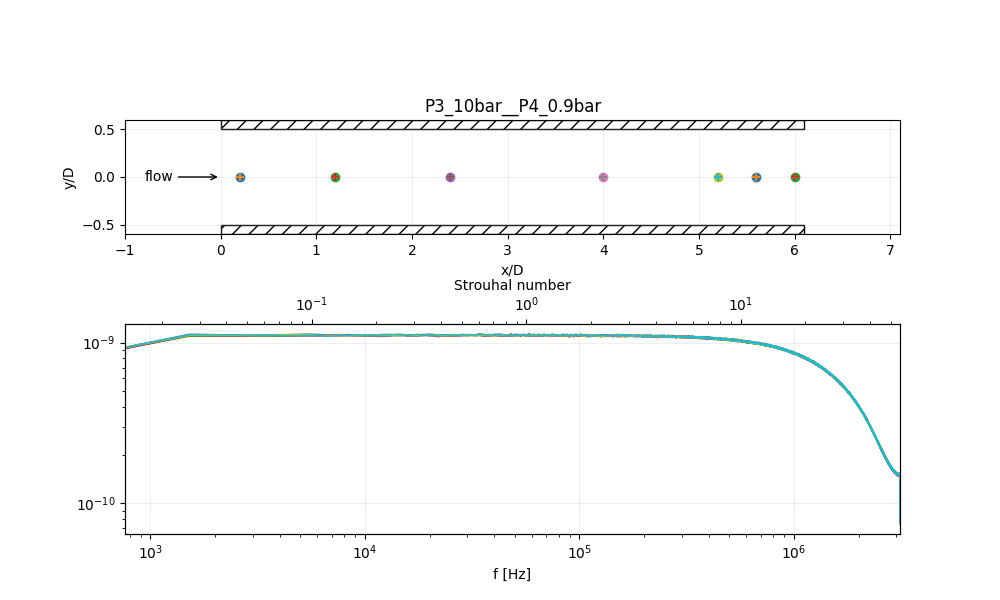

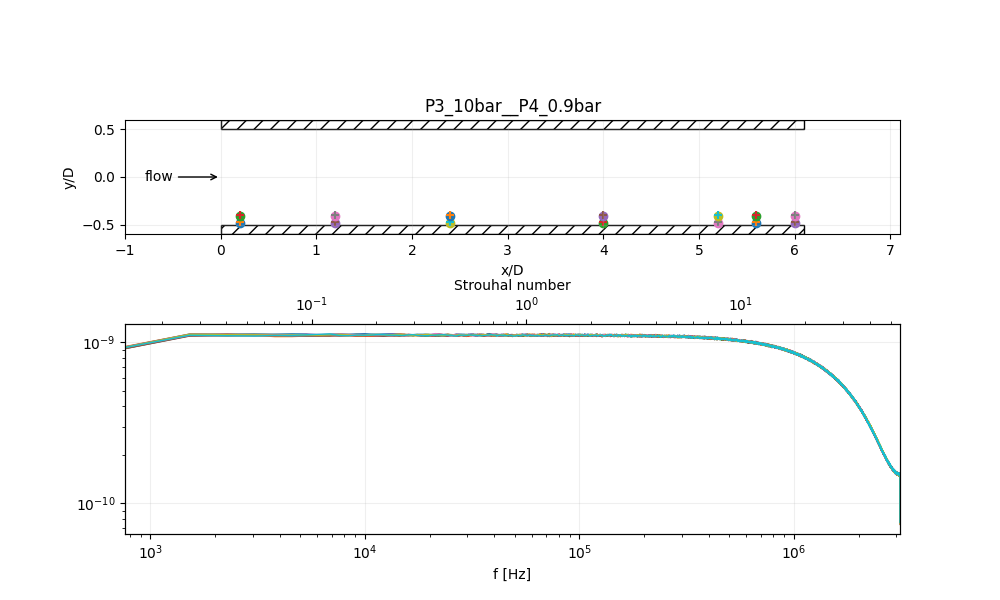

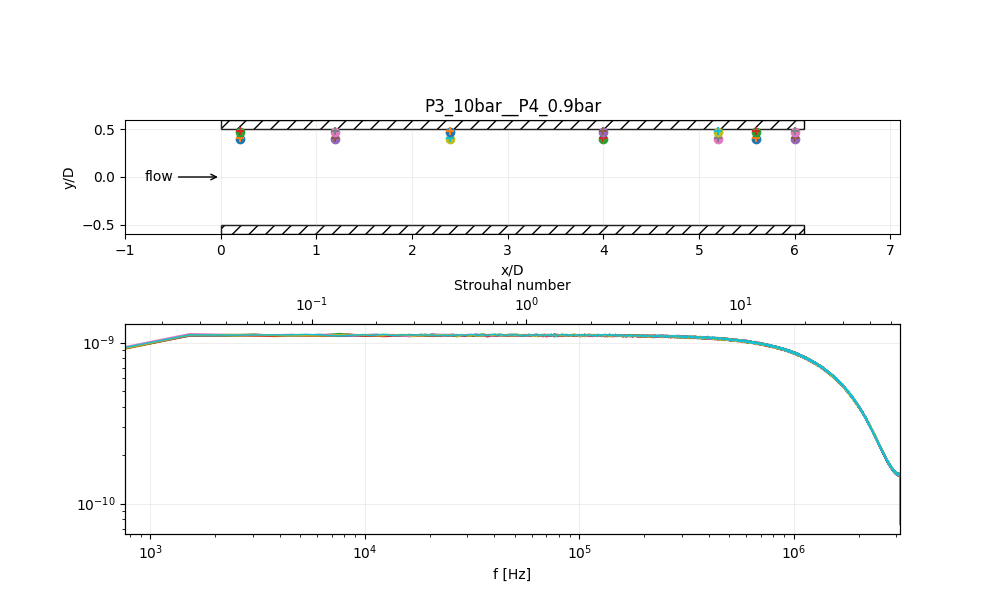

In [365]:
# Open files
bg_data = [f for f in hdf5_files if 'bkgnd' in f][0]
H_bg = h5py.File(bg_data,'r')
H_fg = h5py.File(fg_data,'r')

# Get coordinates
x = H_fg['Y'][:,0]/D
y = H_fg['X'][:,0]/D
coord_bg = H_bg['Y'][:,0]/D - 1j*H_bg['X'][:,0]/D

# Group coordinates
y_grp = (y<=-0.1) + 2*(y>=0.1)
#print(y_grp) ; raise RuntimeError

for y_grp_i in range(np.max(y_grp)+1):

    # Make Figure for geometry (nozzle)
    fig=plt.figure(figsize=(10,6))
    ax_noz=plot_nozzle_coords(fig.add_subplot(211))
    plt.title(os.path.splitext(os.path.basename(fg_data))[0]); plt.xlabel('x/D'); plt.ylabel('y/D');
    
    # Make Figure for spectra
    ax=fig.add_subplot(212)
    plt.grid(alpha=.2)
    plt.xlabel('f [Hz]')
    ll=[]
    
    # Loop through selected coordinates
    for i in range(np.min((len(x),len(coord_bg)))):

        if y_grp[i] != y_grp_i: continue # skip if not in group
        
        datalabel = "%s x/D=%.3f y/D=%.3f" % (os.path.splitext(os.path.basename(fg_data))[0], x[i],y[i])
        
        # find matching coordinate in H_bg
        distance = np.abs( x[i] + 1j*y[i] - coord_bg )
        i_bg = np.where(distance==np.nanmin(distance))[0][0]
        
        # plot coordinates on image of nozzle
        ax_noz.scatter(x[i],y[i],label=datalabel,marker='o')
        ax_noz.scatter(np.real(coord_bg[i_bg]),np.imag(coord_bg[i_bg]),label='bkgnd',marker='+')
        
        # plot spectra below
        #f_bg, Pxx_bg = get_combined_spectra(H_bg)
        #f_fg, Pxx_fg = get_combined_spectra(H_fg)

        f_fg = H_fg['postprocessed/spectra_hi/freq'][0,:]
        Pxx_fg = H_fg['postprocessed/spectra_hi/PIN_spectra'][...]

        f_bg = H_bg['postprocessed/spectra_hi/freq'][0,:]
        Pxx_bg = H_bg['postprocessed/spectra_hi/PIN_spectra'][...]

        
        
        ax.loglog(f_bg, (Pxx_bg[i,:]), label="bkgnd", lw=1);
        plotHandle, = ax.loglog(f_fg, (Pxx_fg[i,:]) , label=datalabel, lw=1);
        ll.append(plotHandle)
    
    ax.set_xlim(f_bg[1], f_bg[-1])
    ax2=ax.twiny();
    ax2.set_xscale('log');
    plt.xlim(Strouhal(f_bg[1],dP), Strouhal(f_bg[-1],dP))
    plt.xlabel('Strouhal number')
    #plt.ylim(0,2e-4)
    #plt.legend(ll,[h.get_label() for h in ll]);

H_bg.close()
H_fg.close()
